# Correlation Analysis

## Research Question
> Are property prices in Mexico more influenced by property size or by location?

## What This Notebook Does
In Lesson 2 we visualized the data and saw patterns. Now we quantify 
those patterns using correlation analysis:
- Calculate the overall correlation between size and price
- Build a correlation heatmap
- Investigate whether correlation differs by state (Simpson's Paradox)
- Investigate whether correlation differs by property type
- Engineer a new feature: price per m²

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# clean dataset
data = pd.read_csv("../data/mexico-real-estate-combined-clean.csv")

print(f"Dimensions: {data.shape[0]} rows and {data.shape[1]} columns.")
data.head()

Dimensions: 1736 rows and 6 columns.


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


## 2. Overall Correlation Between Size and Price

Pearson correlation measures the strength and direction of the 
linear relationship between two numerical variables.

- **1.0** = perfect positive relationship
- **0.0** = no relationship
- **-1.0** = perfect negative relationship

A value above 0.5 is generally considered a moderate to strong relationship.

In [2]:
corr_price_area = (
    data["area_m2"]
    .corr(data["price_usd"])
)

print(f"Correlation between Area and Price: {corr_price_area:.4f}")

Correlation between Area and Price: 0.5855


**Finding:** The overall correlation between area and price is moderate 
and positive — larger properties tend to cost more. However a single 
number across all states may be hiding very different patterns by location.

## 3. Correlation Heatmap

A heatmap shows all pairwise correlations at once.
Red = strong positive, Blue = strong negative, White = no relationship.

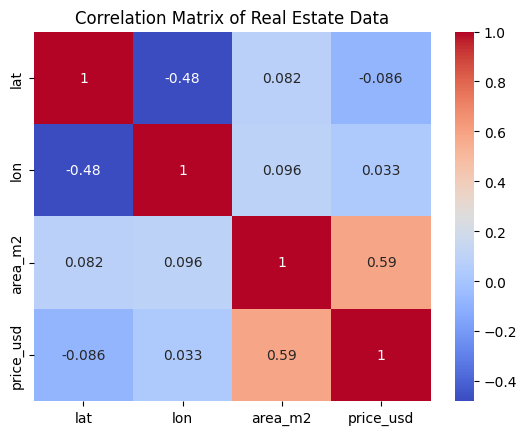

In [3]:
# Compute correlation matrix on numerical columns only
corr_matrix = (
    data
    .select_dtypes("number")
    .corr()
)

fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix of Real Estate Data")
plt.show()

**Finding:** The heatmap confirms that `area_m2` and `price_usd` have 
the strongest correlation among all numerical variables. 
Latitude and longitude show weaker relationships with price, 
though location still matters as we saw in the boxplots.

## 4. Correlation by State — Does Location Change Everything?

A single national correlation number can be misleading if the 
relationship between size and price differs dramatically across states. 
This is known as **Simpson's Paradox** — a pattern that appears 
in aggregate data can disappear or reverse when broken into subgroups.

We use `groupby()` to calculate a separate correlation for each state.

In [4]:
correlations_by_state = (
    data
    .groupby("state")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
    .sort_values(ascending=False)
)

print("Top 5 states — strongest size-price correlation:")
print(correlations_by_state.head(5))
print("\nBottom 5 states — weakest size-price correlation:")
print(correlations_by_state.tail(5))

Top 5 states — strongest size-price correlation:
state
Zacatecas              1.000000
Colima                 0.988235
Sonora                 0.911524
Durango                0.909258
Baja California Sur    0.880583
Name: price_usd, dtype: float64

Bottom 5 states — weakest size-price correlation:
state
Nuevo León                         0.578696
Veracruz de Ignacio de la Llave    0.567469
Distrito Federal                   0.410704
Tabasco                            0.241284
Oaxaca                            -1.000000
Name: price_usd, dtype: float64


**Finding:** The correlation varies enormously by state:
- Some states show a strong correlation (0.7+) — size reliably predicts price
- Others show a near-zero or even negative correlation — size barely matters

This confirms what the small multiples in Lesson 2 showed visually: 
**location changes not just the price level but how much size matters at all.**
This is Simpson's Paradox in action — the national average correlation 
describes no individual state accurately.

## 5. Correlation by Property Type

In [5]:
correlations_by_prop = (
    data
    .groupby("property_type")
    [["area_m2", "price_usd"]]
    .corr()
    .iloc[:, 1]
    .xs("area_m2", level=1)
)

print("Correlation between area and price by property type:")
print(correlations_by_prop)

Correlation between area and price by property type:
property_type
apartment    0.519021
house        0.719280
Name: price_usd, dtype: float64


**Finding:** Houses and apartments show different correlations 
between size and price. This suggests that the type of property 
affects how much size drives the price — further evidence that 
a single overall number oversimplifies the market.

## 6. Feature Engineering — Price Per m²

The median price comparison between houses and apartments was 
misleading in Lesson 2 — they had similar total prices but 
apartments are smaller. 

A fairer comparison is **price per square meter** — 
how much does each m² cost? This normalizes for size 
and reveals the true value difference.

In [6]:
# Create new column: price per square meter
df = (
    data
    .assign(price_per_m2=lambda x: x["price_usd"] / x["area_m2"])
)

print("New column added:")
df[["property_type", "state", "area_m2", "price_usd", "price_per_m2"]].head()

New column added:


,property_type,state,area_m2,price_usd,price_per_m2
0,house,Estado de México,150.0,67965.56,453.103733
1,house,Nuevo León,186.0,63223.78,339.912796
2,apartment,Guerrero,82.0,84298.37,1028.028902
3,apartment,Guerrero,150.0,94308.80,628.725333
4,house,Yucatán,205.0,105191.37,513.128634


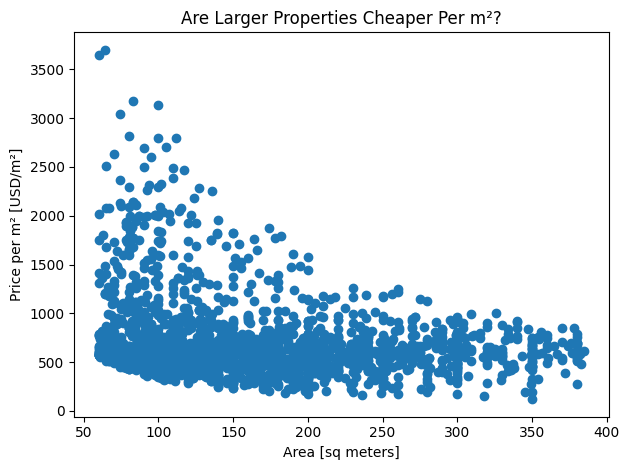

In [7]:
# Does price per m² decrease as property gets larger?
fig, ax = plt.subplots()
ax.scatter(x=df["area_m2"], y=df["price_per_m2"])
ax.set_title("Are Larger Properties Cheaper Per m²?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m² [USD/m²]")
plt.tight_layout()
plt.show()

**Finding:** Larger properties tend to have a lower price per m² — 
there is a clear downward pattern. This means buying more space 
becomes relatively cheaper as the property gets bigger. 
Small properties (apartments) command a premium per square meter.

## Key Findings Summary

| Finding | Evidence |
|---|---|
| Overall size-price correlation is moderate | Pearson r ≈ 0.5–0.6 |
| Correlation varies dramatically by state | Some states 0.7+, others near zero |
| Simpson's Paradox confirmed | National average hides state differences |
| Property type affects the relationship | Houses vs apartments show different correlations |
| Larger properties are cheaper per m² | Scatterplot of price_per_m2 vs area shows downward trend |

**Next step:** Lesson 4 will use `price_per_m2` to do a deeper 
location analysis and answer our research question definitively.